In [10]:
# Importamos la librería pandas, que se usa para manipulación y análisis de datos
import pandas as pd

# Leemos el dataset desde una URL y lo guardamos en un DataFrame llamado total_data
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")

# Mostramos las primeras 5 filas del dataset para entender su estructura
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
import os

os.makedirs("../data/raw", exist_ok=True)

total_data.to_csv("../data/raw/total_data.csv", index=False)

#Creo carpeta para guardarn datos

In [ ]:
total_data.to_csv("../data/raw/total_data.csv", index = False)

#guardo datos

In [13]:
#Exploracion y limpieza de datos:

In [ ]:
# Obtenemos dimensiones
total_data.shape

(48895, 16)

El DataFrame contiene 48.895 filas y 16 columnas.

In [ ]:
# Obtenemos informacion sobre los tipos de datos y los valores nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

 Clasificación de variables

Las variables pueden clasificarse no solo por su tipo de dato, sino por su significado:

Variables categóricas
Incluyen aquellas que representan etiquetas o identificadores:

- `id`, `host_id`: identificadores únicos (no tienen valor analítico)
- `name`, `host_name`: texto descriptivo
- `neighbourhood_group`, `neighbourhood`: ubicación
- `room_type`: tipo de alojamiento

Variables numéricas
Variables que representan cantidades y permiten análisis matemático:

- `price`, `minimum_nights`, `number_of_reviews`
- `reviews_per_month`, `calculated_host_listings_count`
- `availability_365`

 Variable especial
- `last_review`: aunque aparece como texto, representa una fecha y debería convertirse a formato datetime para su análisis.

---

 Conclusión

Es importante distinguir entre tipo de dato técnico y significado real de la variable, ya que esto influye directamente en el tipo de análisis que se puede realizar.

In [18]:
# Contamos cuántos valores duplicados hay en cada columna

print(f"El número de registros duplicados en 'name' es: {total_data['name'].duplicated().sum()}")

print(f"El número de registros duplicados en 'host_id' es: {total_data['host_id'].duplicated().sum()}")

print(f"El número de registros duplicados en 'id' es: {total_data['id'].duplicated().sum()}")

El número de registros duplicados en 'name' es: 989
El número de registros duplicados en 'host_id' es: 11438
El número de registros duplicados en 'id' es: 0


Análisis de valores duplicados

Tras analizar los valores duplicados en las columnas `name`, `host_id` e `id`, se obtienen las siguientes observaciones:

- La columna `name` presenta valores duplicados. Esto es esperable, ya que diferentes alojamientos pueden tener nombres iguales o similares (por ejemplo: "House in Brooklyn").

- La columna `host_id` también contiene valores duplicados, lo cual es normal, dado que un mismo anfitrión puede gestionar múltiples propiedades en Airbnb.

- La columna `id` no presenta valores duplicados, lo que indica que cada registro del dataset es único y está correctamente identificado.

 Conclusión

La presencia de duplicados en `name` y `host_id` no representa un problema para el análisis. Sin embargo, es fundamental que la columna `id` sea única, ya que actúa como identificador de cada alojamiento. En este caso, los datos muestran consistencia y buena calidad en este aspecto.

In [19]:
#Eliminamos informacion irrelevante

total_data.drop([
    "id",                  # Identificador único (no aporta valor analítico)
    "name",                # Texto libre (difícil de analizar)
    "host_name",           # Información irrelevante
    "last_review",         # Muchos valores nulos y no transformado a fecha
    "reviews_per_month",   # Muchos valores faltantes
    "host_id"              # Identificador del anfitrión (sin valor analítico)
], axis=1, inplace=True)

# Mostramos las primeras filas del dataset limpio
total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


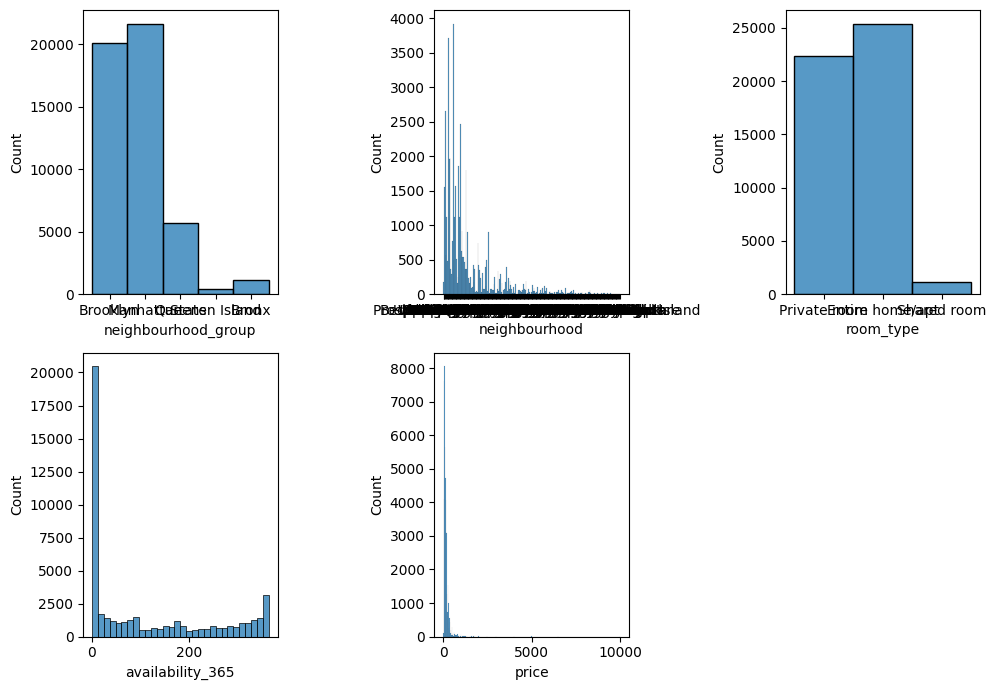

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 3, figsize=(10, 7))

# Histogramas
sns.histplot(ax=axis[0,0], data=total_data, x="neighbourhood_group")
sns.histplot(ax=axis[0,1], data=total_data, x="neighbourhood")
sns.histplot(ax=axis[0,2], data=total_data, x="room_type")
sns.histplot(ax=axis[1,0], data=total_data, x="availability_365")
sns.histplot(ax=axis[1,1], data=total_data, x="price")

# Eliminamos subplot vacío
fig.delaxes(axis[1, 2])

plt.tight_layout()
plt.show()

 Interpretación de los histogramas

A partir del análisis visual de las variables seleccionadas, se pueden extraer las siguientes conclusiones:

- Se observa que existen algunos anfitriones con un número elevado de propiedades disponibles para alquiler, lo que indica la presencia de hosts con múltiples listings. Además, en algunas variables relacionadas con anfitriones se detectan valores nulos.

- El dataset está compuesto únicamente por los cinco distritos de Nueva York: Brooklyn, Manhattan, Queens, Staten Island y Bronx. Esto confirma que el análisis se centra exclusivamente en esta ciudad.

- Algunos barrios presentan una mayor concentración de alojamientos en Airbnb que otros, lo que sugiere una distribución desigual de la oferta dentro de la ciudad.

- En cuanto al tipo de habitación, predominan los apartamentos o viviendas completas frente a las habitaciones privadas, mientras que las habitaciones compartidas son las menos frecuentes.

- La variable `availability_365` muestra que muchos alojamientos están disponibles durante todo el año. Sin embargo, también se observan valores iguales a 0 o nulos, lo que podría indicar datos faltantes o propiedades sin disponibilidad registrada.

---

Conclusión

Este análisis permite entender mejor la estructura del mercado de Airbnb en Nueva York, identificando patrones claros en la distribución geográfica, tipo de alojamiento y disponibilidad, así como posibles problemas de calidad en los datos.

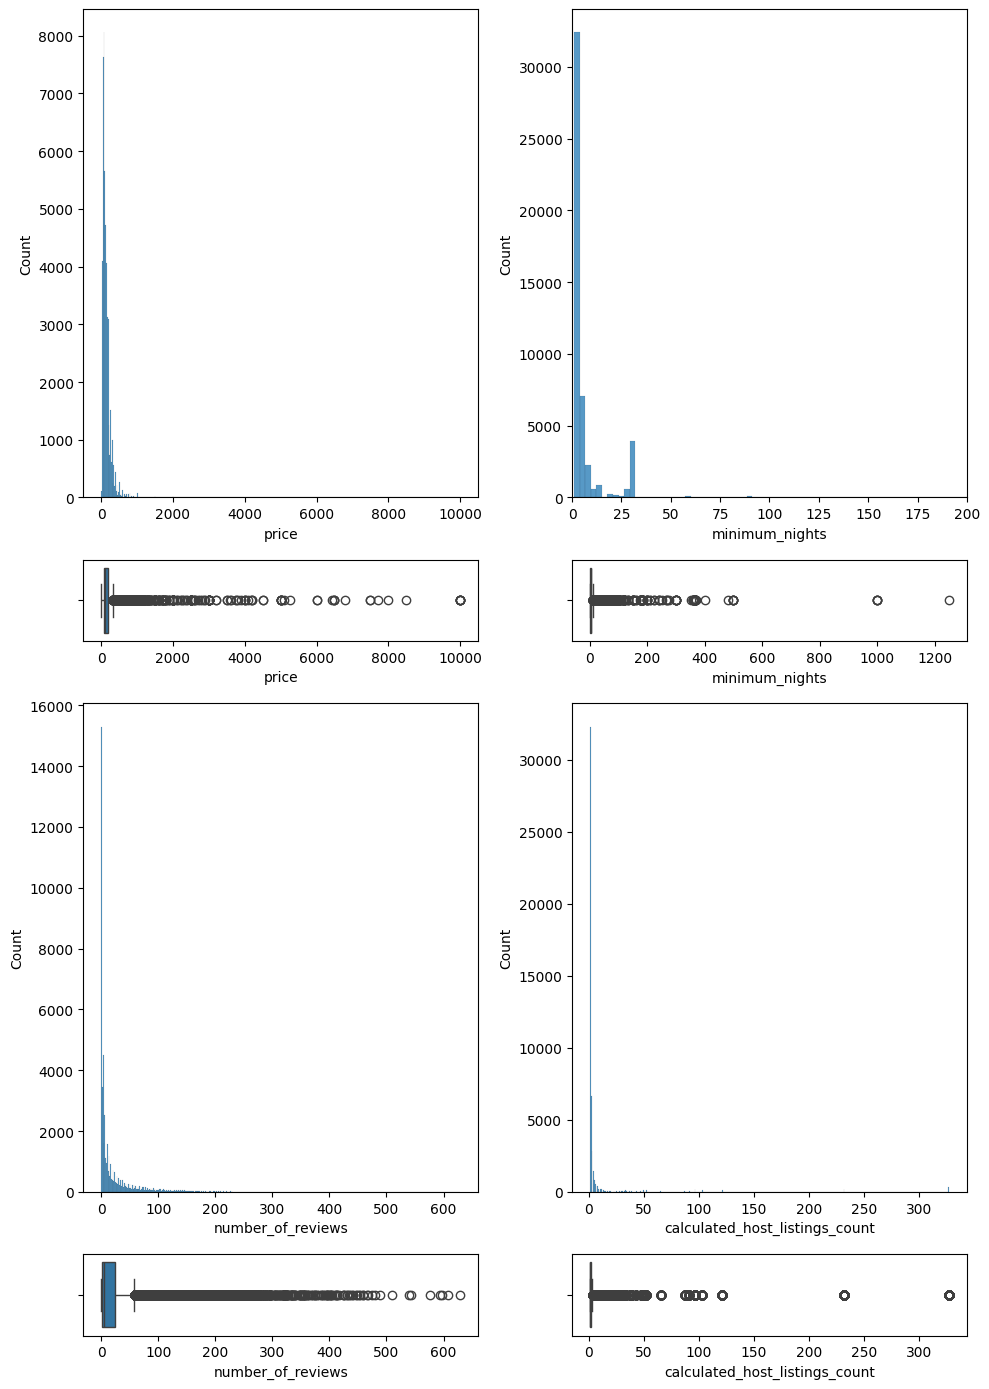

In [25]:
#Analisis de valores numericas
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "price")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "price")

sns.histplot(ax = axis[0, 1], data = total_data, x = "minimum_nights").set_xlim(0, 200)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "minimum_nights")

sns.histplot(ax = axis[2, 0], data = total_data, x = "number_of_reviews")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "number_of_reviews")

sns.histplot(ax = axis[2,1], data = total_data, x = "calculated_host_listings_count")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "calculated_host_listings_count")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


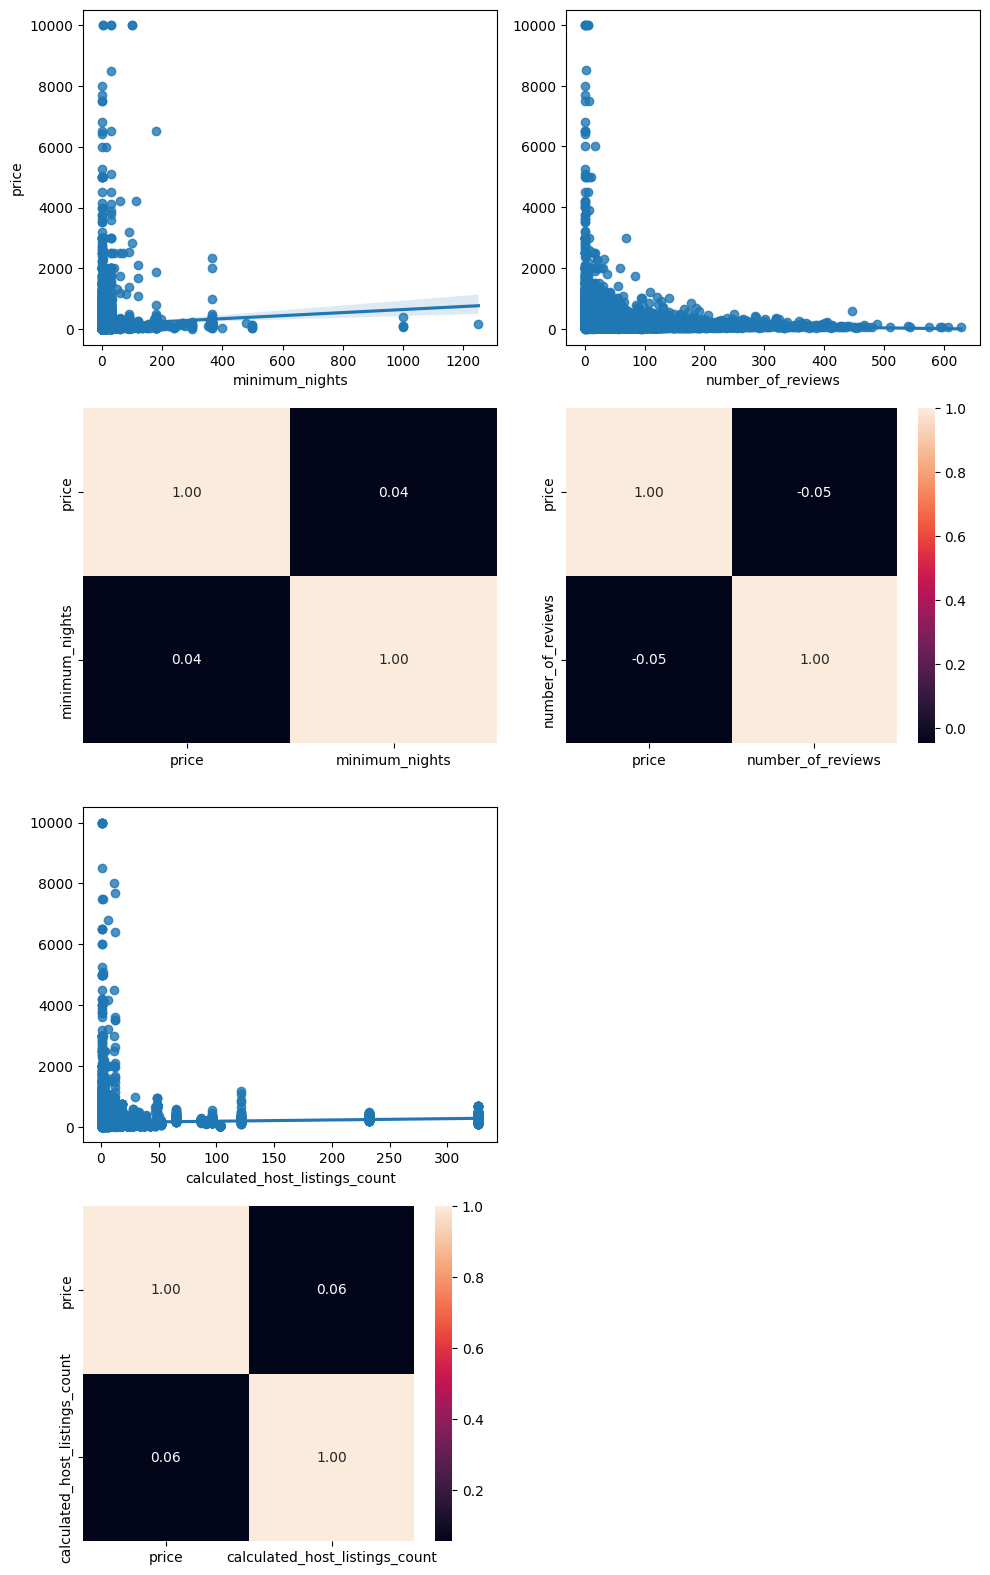

In [27]:
#Analisis numerico

# Creaamos
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Creamos graficos
sns.regplot(ax = axis[0, 0], data = total_data, x = "minimum_nights", y = "price")
sns.heatmap(total_data[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "number_of_reviews", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "calculated_host_listings_count", y = "price").set(ylabel = None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Ajustamos
plt.tight_layout()

# Mostramos
plt.show()

 Análisis combinado de variables numéricas: distribución, outliers y relaciones

En este apartado se combinan dos tipos de análisis sobre las variables numéricas del dataset de Airbnb:

1. Análisis de distribución mediante histogramas y boxplots.
2. Análisis de relaciones entre variables mediante regresiones y correlaciones.


 Análisis de distribución y valores atípicos

Se han analizado las siguientes variables:

- `price` (precio)
- `minimum_nights` (noches mínimas)
- `number_of_reviews` (número de reseñas)
- `calculated_host_listings_count` (cantidad de propiedades por anfitrión)

 Observaciones principales

- La variable **precio (`price`)** presenta una distribución fuertemente asimétrica, con la mayoría de los valores concentrados en rangos bajos y algunos valores extremadamente altos (outliers).

- En **noches mínimas (`minimum_nights`)** se observa que la mayoría de los alojamientos requieren estancias cortas, aunque existen casos aislados con valores muy elevados.

- El **número de reseñas (`number_of_reviews`)** muestra que la mayoría de los alojamientos tiene pocas reseñas, mientras que unos pocos concentran gran actividad.

- La variable **propiedades por anfitrión (`calculated_host_listings_count`)** indica que la mayoría de hosts gestionan pocas propiedades, aunque existen algunos con una gran cantidad de anuncios.

---
 2. Análisis de relaciones con el precio

Se ha estudiado la relación entre el precio y otras variables numéricas mediante gráficos de regresión y matrices de correlación.

 Relaciones observadas

- **Precio vs noches mínimas (`minimum_nights`)**: no se observa una relación lineal fuerte, aunque algunos valores altos de noches mínimas pueden estar asociados a precios más elevados.

- **Precio vs número de reseñas (`number_of_reviews`)**: la relación es débil o negativa, lo que sugiere que los alojamientos más baratos tienden a recibir más reseñas.

- **Precio vs propiedades por anfitrión (`calculated_host_listings_count`)**: no se observa una correlación significativa entre ambas variables.

---

 Conclusión general

El análisis muestra que el precio de los alojamientos no depende fuertemente de las variables analizadas de forma individual, aunque sí se observan patrones interesantes en la distribución de los datos y la presencia de valores atípicos.

Esto sugiere que el precio puede estar influido por otras variables no incluidas en este análisis, como la ubicación específica o el tipo de habitación.

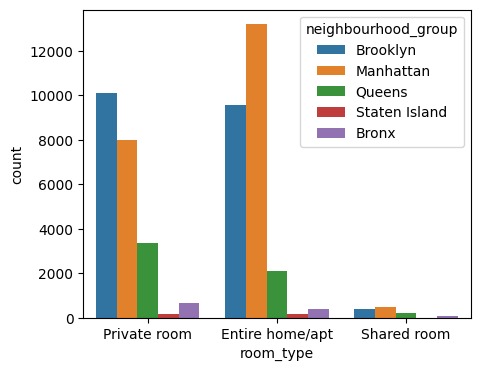

In [29]:
#Analisis categorico
fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = total_data, x = "room_type", hue = "neighbourhood_group")

# Show the plot
plt.show()

 Análisis de variables categóricas

A partir del análisis de las variables categóricas del dataset, especialmente la relación entre `neighbourhood_group` (distrito) y `room_type` (tipo de habitación), se pueden extraer las siguientes conclusiones:

---

 Distribución por distrito

- **Manhattan** es el distrito con mayor número de alojamientos registrados en Airbnb, destacando además por una alta concentración de **apartamentos completos (entire home/apt)**. Esto indica un mercado más orientado a alquileres turísticos completos.

- **Brooklyn** es el segundo distrito con mayor presencia en la plataforma. Sin embargo, presenta una mayor proporción de **habitaciones privadas**, lo que sugiere que muchos anfitriones comparten su vivienda o buscan rentabilizar espacios dentro de sus hogares.

- **Queens** y **Bronx** ocupan el tercer y cuarto lugar respectivamente. Ambos siguen un patrón similar al de Brooklyn, con una mezcla de tipos de habitaciones y menor volumen total de oferta.

- **Staten Island** presenta una presencia muy reducida en el dataset, lo que indica que no es un área especialmente relevante para el mercado de Airbnb en Nueva York.

---

 Relación entre tipo de habitación y distrito

En general, no se observa una relación extremadamente fuerte entre el tipo de habitación y el distrito, aunque sí existen tendencias claras:

- Manhattan se asocia más a alojamientos completos.
- Brooklyn y otros distritos tienden a ofrecer más habitaciones privadas.


 Conclusión

El análisis sugiere que la ubicación geográfica influye parcialmente en el tipo de alojamiento ofrecido, aunque no es un factor determinante absoluto. Existen patrones claros en Manhattan y Brooklyn, pero en el resto de distritos la distribución es más homogénea.

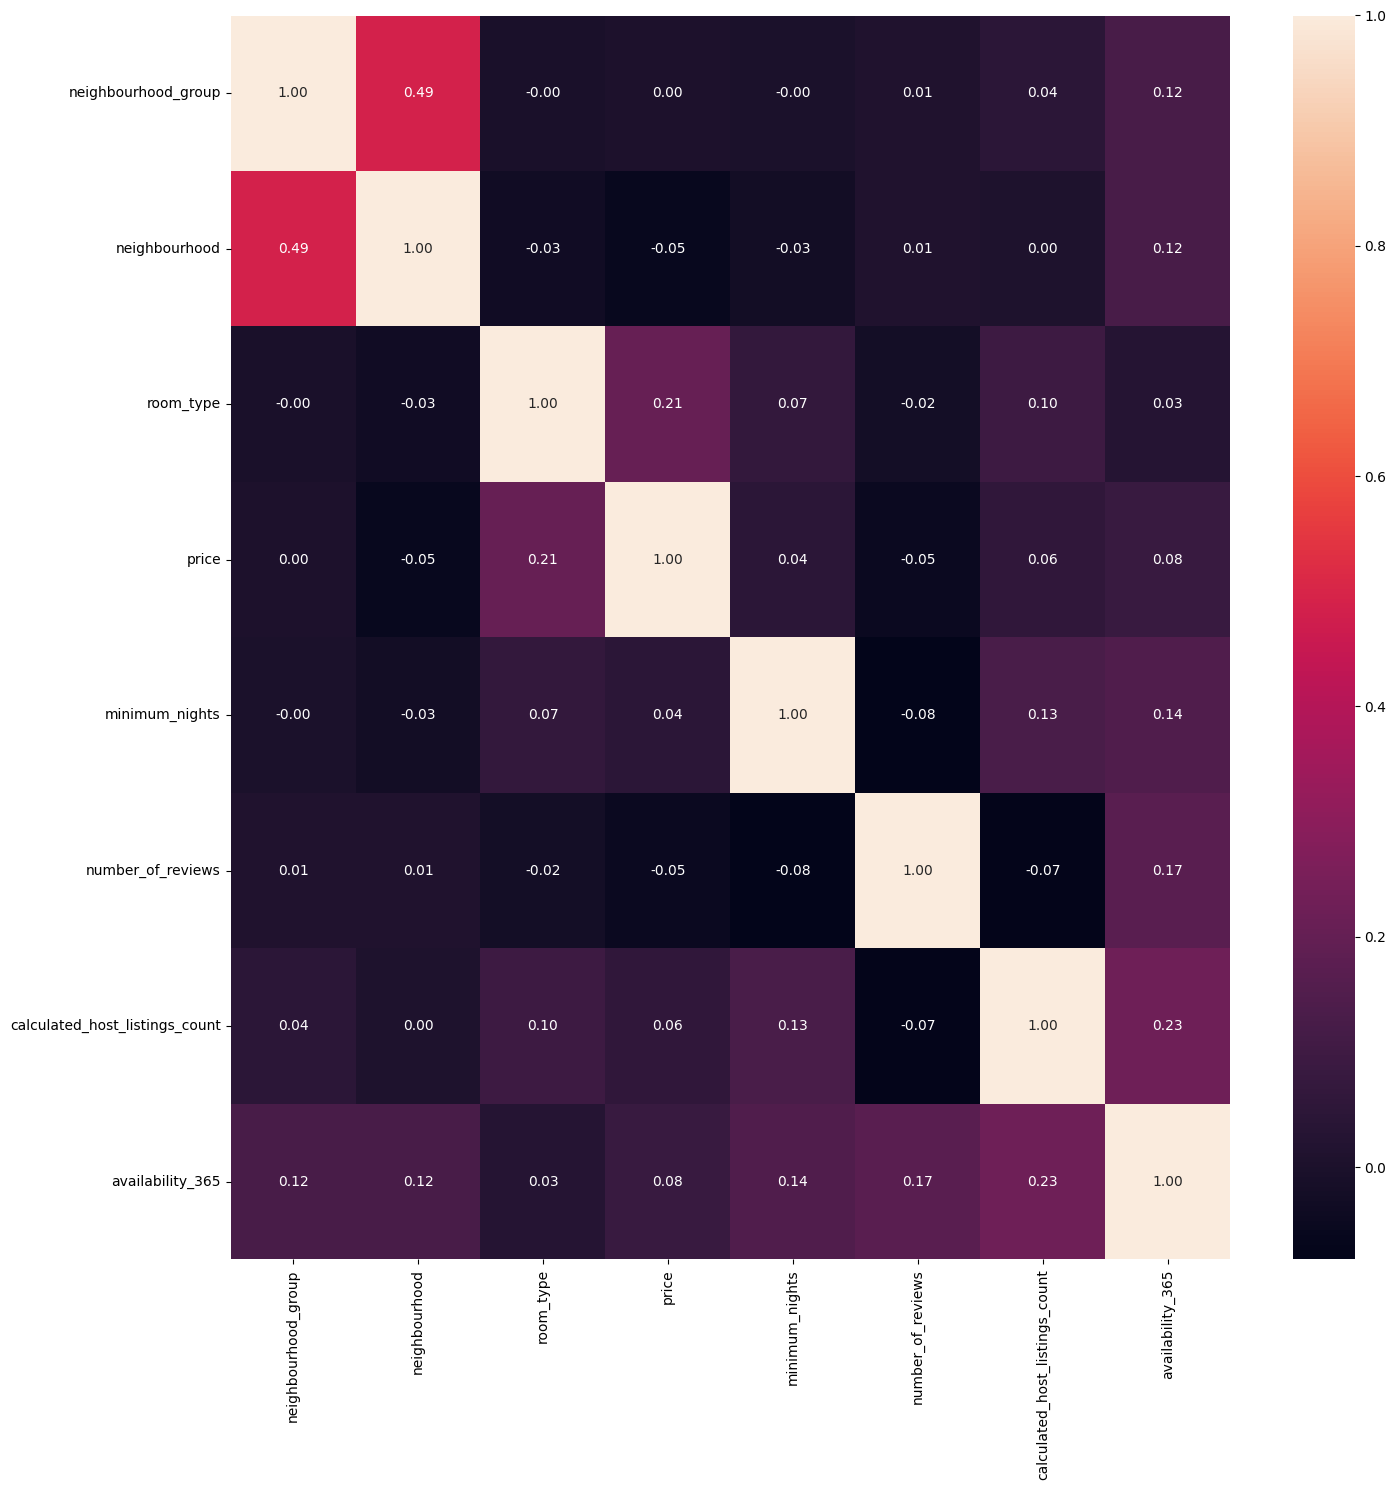

In [ ]:
#Analisis categorico completo

# Factorizamos tipo de room y vecindario
total_data["room_type"] = pd.factorize(total_data["room_type"])[0]
total_data["neighbourhood_group"] = pd.factorize(total_data["neighbourhood_group"])[0]
total_data["neighbourhood"] = pd.factorize(total_data["neighbourhood"])[0]

fig, axes = plt.subplots(figsize=(15, 15))

sns.heatmap(total_data[["neighbourhood_group", "neighbourhood", "room_type", "price", "minimum_nights",	
                        "number_of_reviews", "calculated_host_listings_count", "availability_365"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

# Draw Plot
plt.show()

Análisis de correlaciones entre variables numéricas

En este apartado se estudia la relación entre las variables numéricas del dataset, especialmente su posible influencia sobre el precio (`price`), mediante matrices de correlación y gráficos de regresión.


 Observaciones principales

- En general, se observa una **correlación muy baja entre la mayoría de las variables analizadas**, lo que indica que no existe una relación lineal fuerte entre ellas.

- La única relación ligeramente destacable es que los **anfitriones con un mayor número de anuncios (`calculated_host_listings_count`) tienden a tener una mayor disponibilidad (`availability_365`)**.



Interpretación

- La baja correlación sugiere que variables como `minimum_nights`, `number_of_reviews` o `calculated_host_listings_count` **no explican de forma clara el comportamiento del precio** ni presentan relaciones lineales significativas entre sí.

- Esto indica que el comportamiento del dataset es más complejo y probablemente esté influenciado por factores no incluidos en este análisis, como la ubicación específica, la calidad del alojamiento o la demanda del mercado.



 Conclusión

En este análisis no se identifican relaciones fuertes entre las variables numéricas estudiadas. Por lo tanto, no es posible extraer conclusiones determinantes basadas únicamente en correlaciones lineales, lo que sugiere la necesidad de explorar otros factores o aplicar modelos más complejos para entender mejor los datos.

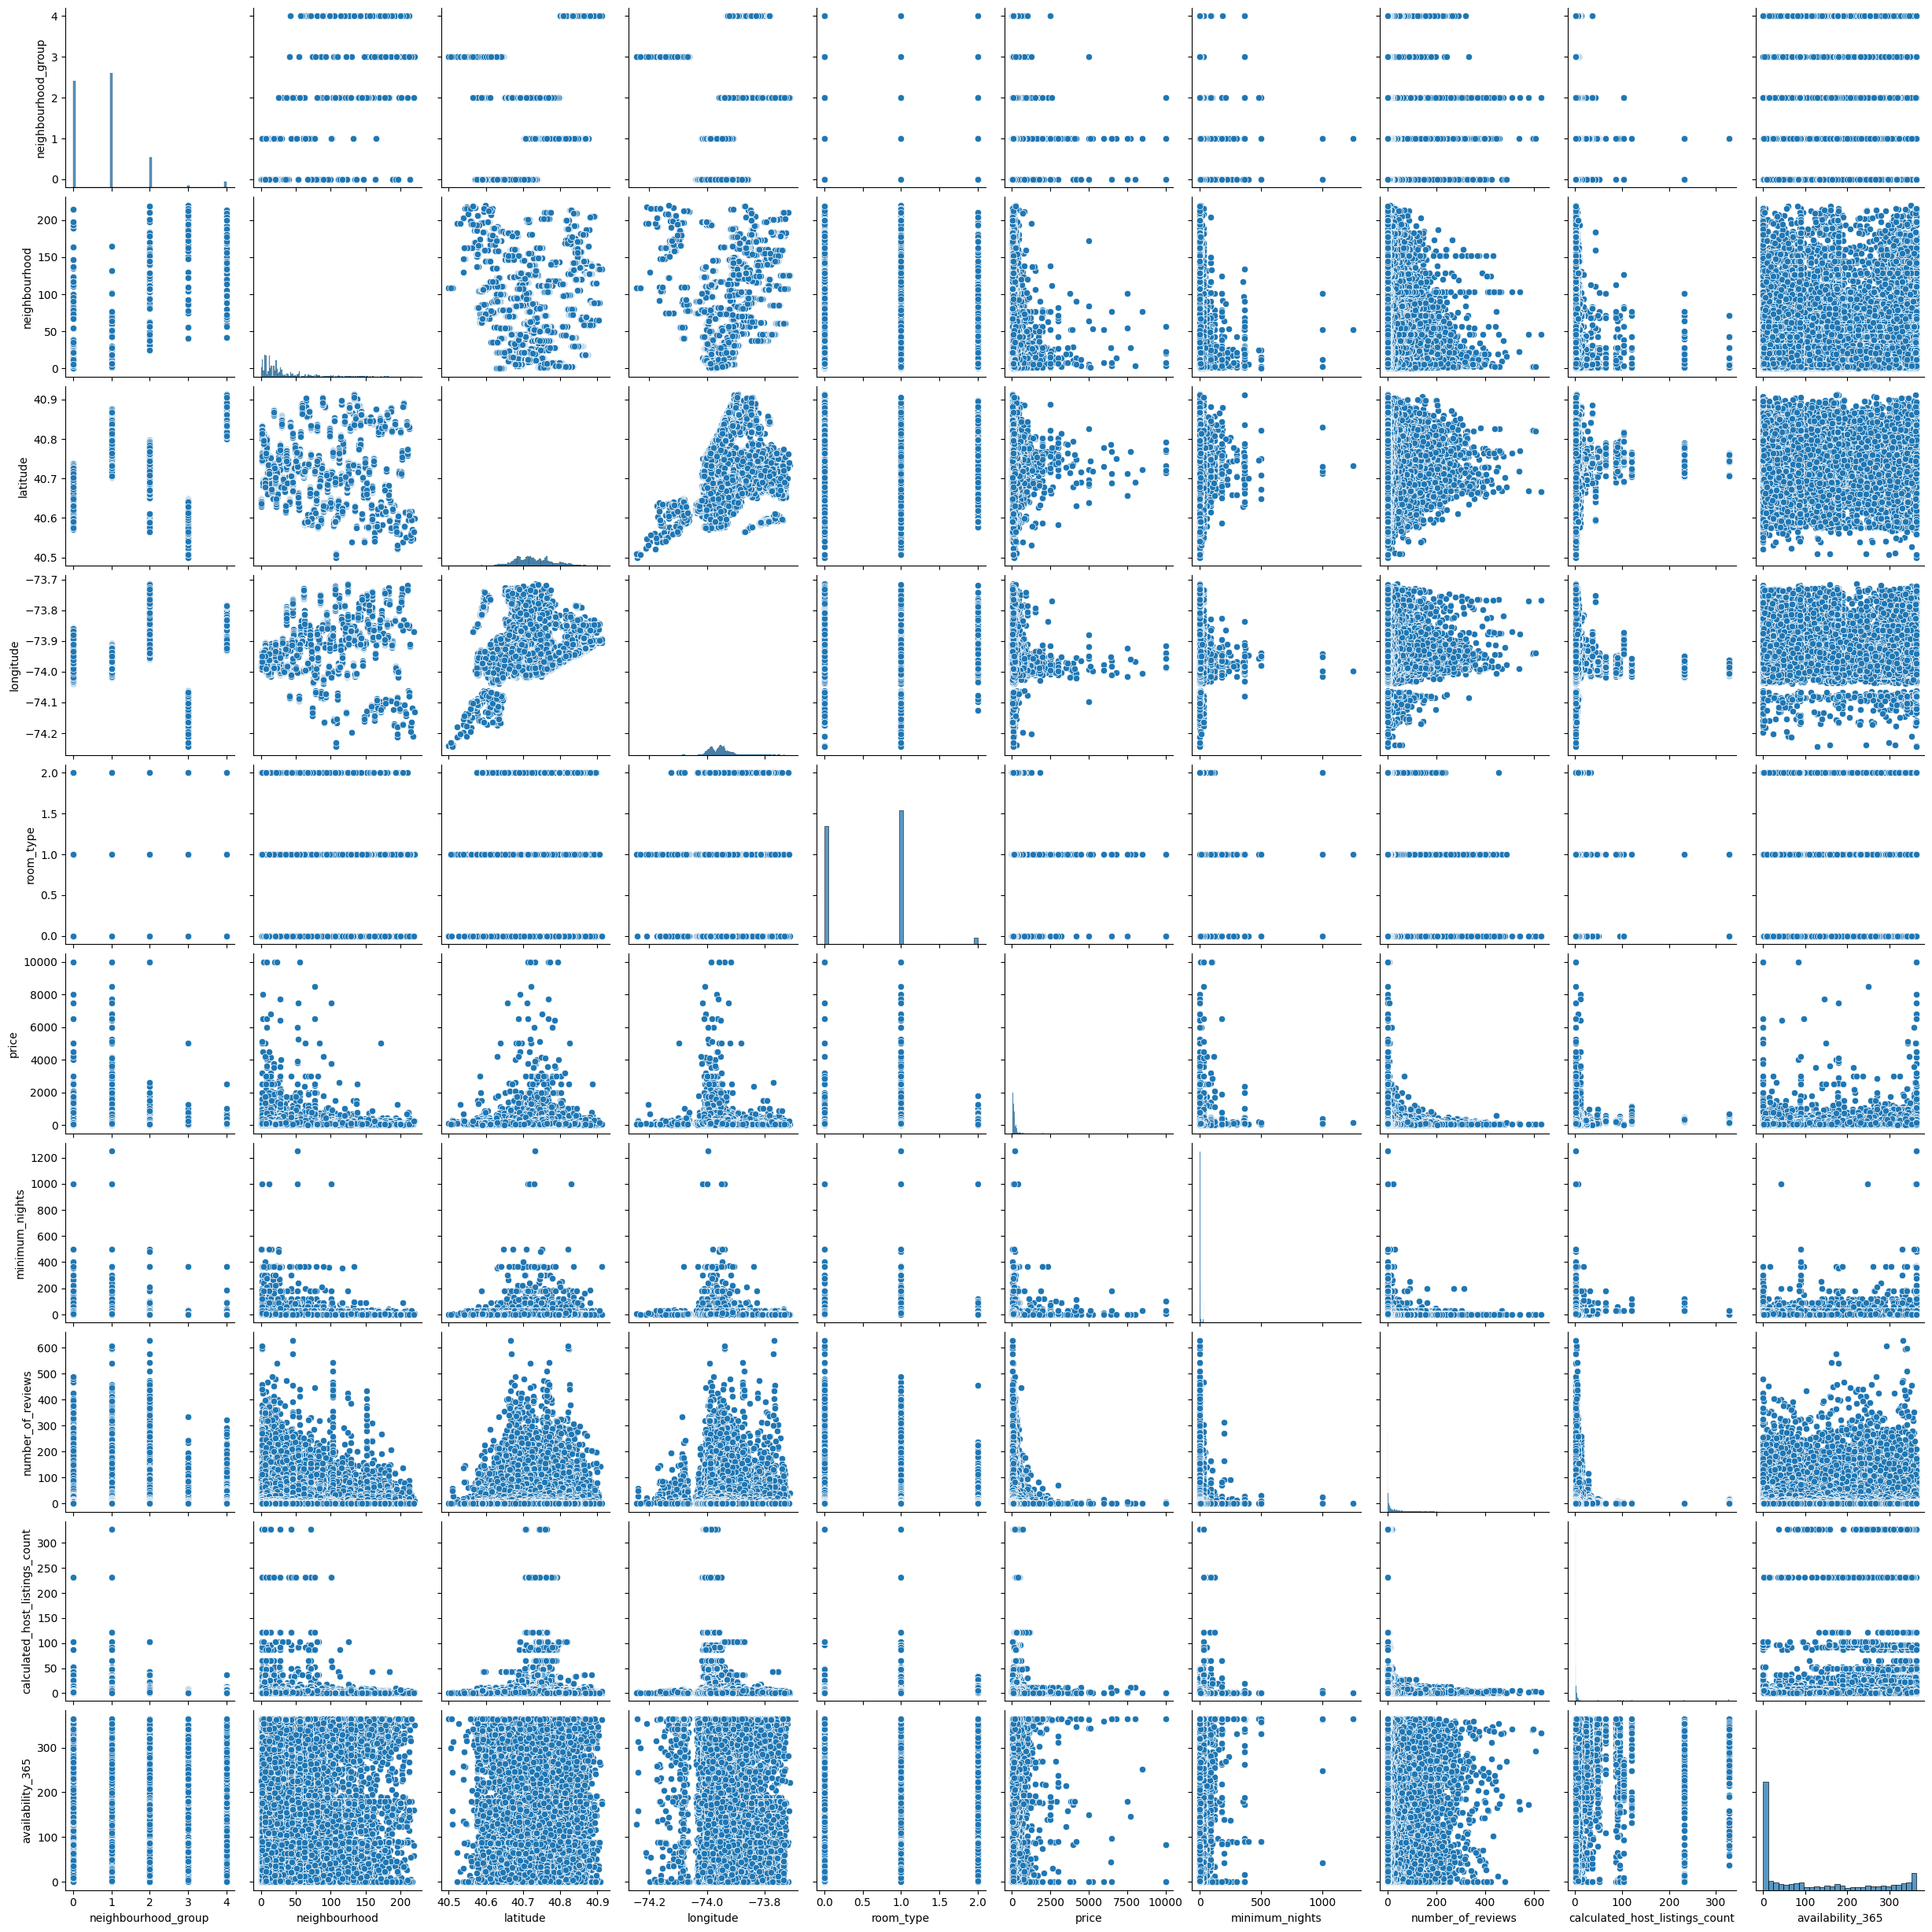

In [32]:
#Analizamos todos los datos a la vez
sns.pairplot(data = total_data)

In [33]:
#Analisis de valores atipicos
total_data.describe()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,0.786911,29.888782,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,7.143982,112.781327
std,0.844386,34.676634,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,32.952519,131.622289
min,0.000000,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,7.500000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,1.000000,0.000000
50%,1.000000,19.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.000000,37.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.000000,227.000000
max,4.000000,220.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,327.000000,365.000000


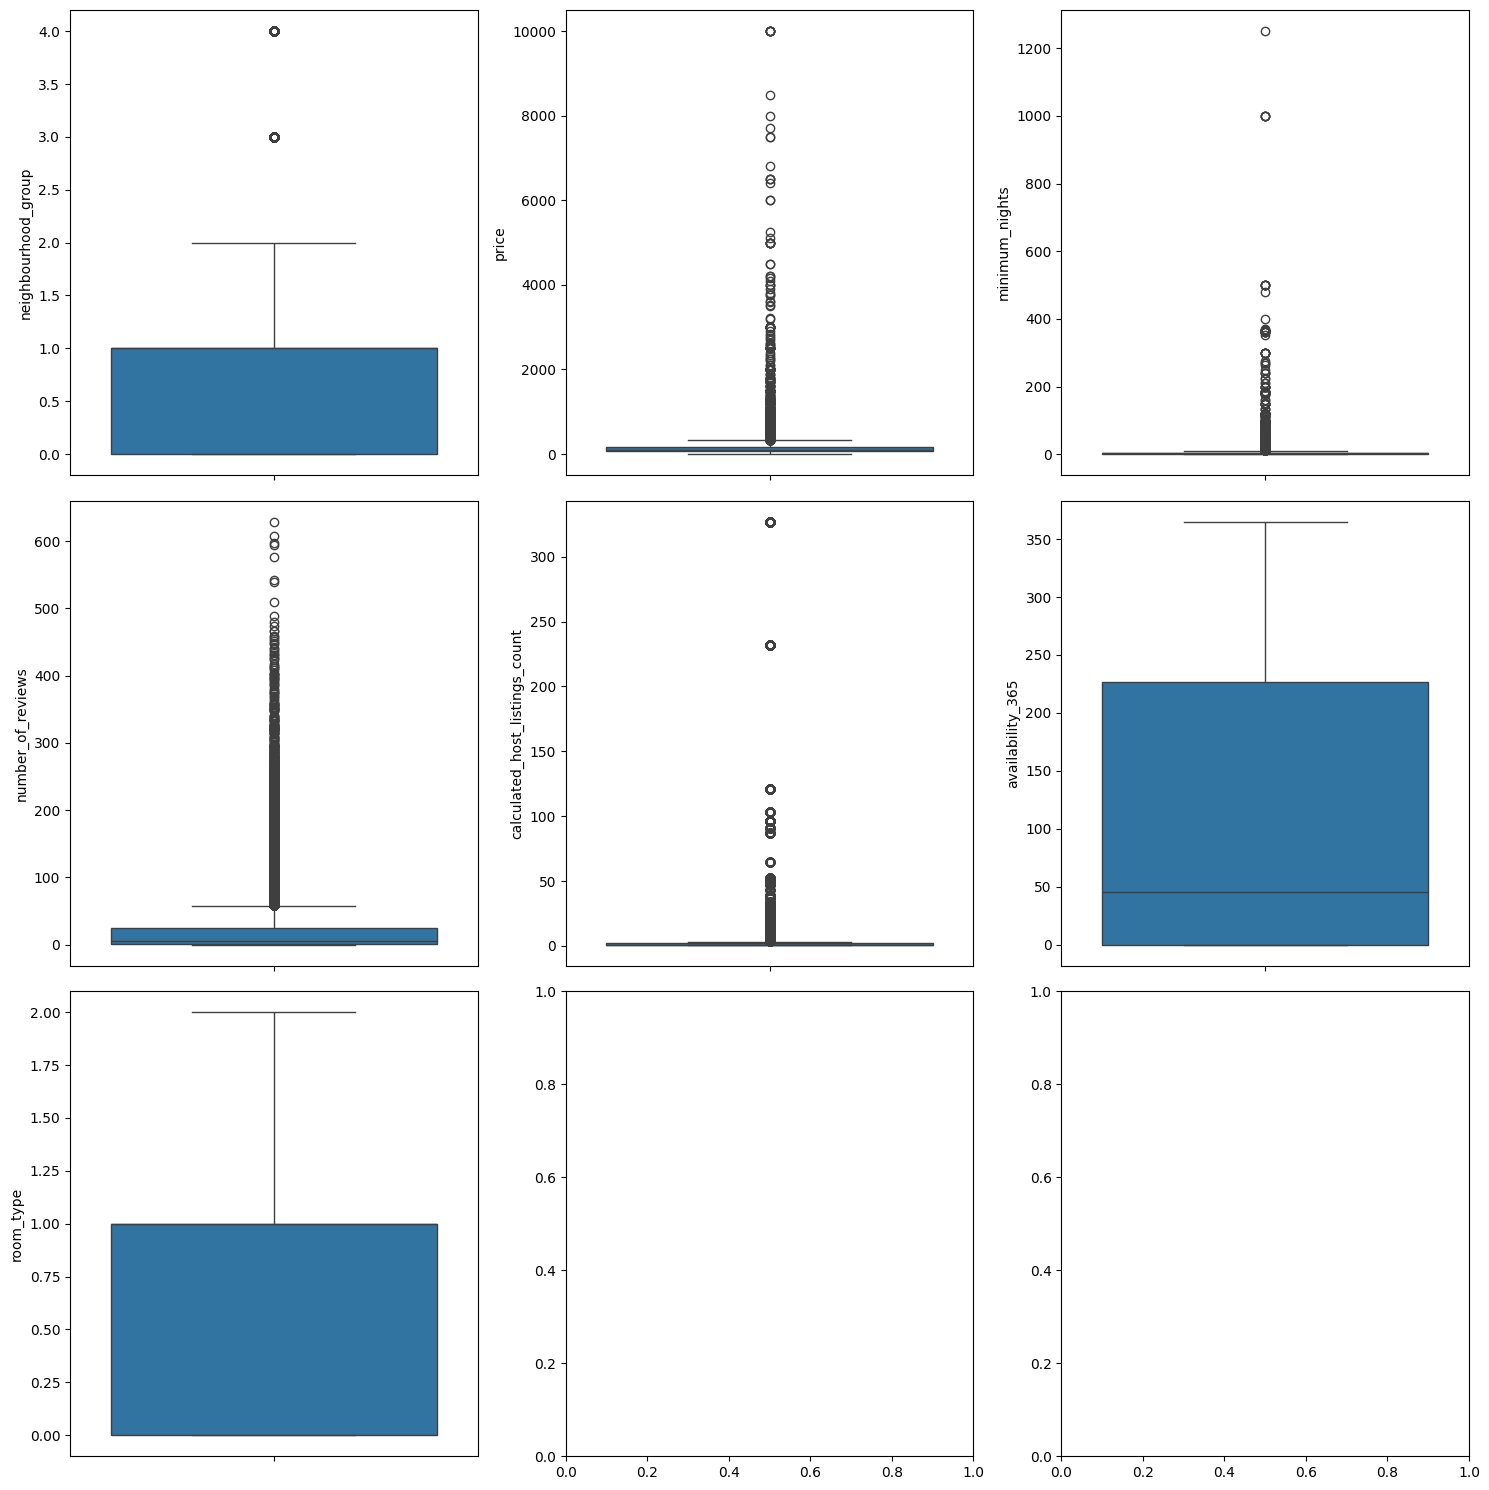

In [34]:
fig, axes = plt.subplots(3, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "neighbourhood_group")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "price")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "minimum_nights")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "number_of_reviews")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "calculated_host_listings_count")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "availability_365")
sns.boxplot(ax = axes[2, 0], data = total_data, y = "room_type")

plt.tight_layout()

plt.show()

In [35]:
#Deteccion de valores atipicos en price
price_stats = total_data["price"].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [38]:


price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"Los límites superior e inferior para detectar valores atípicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(price_iqr, 2)}")

Los límites superior e inferior para detectar valores atípicos son 334.0 y -90.0, con un rango intercuartílico de 106.0


 Detección de valores atípicos en el precio (IQR)

En este apartado se utilizamos el método del rango intercuartílico (IQR) para detectar posibles valores atípicos en la variable `price`.

---

 ¿Qué es el IQR?

El rango intercuartílico (IQR) se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1), y representa el 50% central de los datos.

---

 Cálculo de límites

Se establecen dos límites para detectar outliers:

- **Límite superior**: valores por encima de Q3 + 1.5 * IQR
- **Límite inferior**: valores por debajo de Q1 - 1.5 * IQR

---
 Interpretación

- Los valores fuera de estos límites se consideran posibles valores atípicos.
- En el caso del precio de Airbnb, esto permite identificar alojamientos con precios inusualmente altos o bajos.

---
 Conclusión

El uso del IQR es una técnica estándar para la detección de outliers y es especialmente útil en variables como `price`, donde es común encontrar valores extremos que pueden distorsionar el análisis.

In [ ]:
#Limpiamos
total_data = total_data[total_data["price"] > 0]

In [41]:
cuenta_0 = total_data[total_data["price"] == 0].shape[0]
cuenta_1 = total_data[total_data["price"] == 1].shape[0]

print("Cuenta de 0: ", count_0)
print("Cuenta de 1: ", count_1)

Cuenta de 0:  0
Cuenta de 1:  0


In [ ]:
#Outlier deteccion de noches minimas
nights_stats = total_data["minimum_nights"].describe()
nights_stats


count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [43]:
# Rango intercuartílico (IQR) para noches mínimas

nights_iqr = nights_stats["75%"] - nights_stats["25%"]

upper_limit = nights_stats["75%"] + 1.5 * nights_iqr
lower_limit = nights_stats["25%"] - 1.5 * nights_iqr

print(f"Los límites superior e inferior para detectar valores atípicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(nights_iqr, 2)}")

Los límites superior e inferior para detectar valores atípicos son 11.0 y -5.0, con un rango intercuartílico de 4.0


In [ ]:
#Limpiamos 


total_data = total_data[total_data["minimum_nights"] <= 15]

In [ ]:
# Contamos cuántos registros tienen exactamente 0 noches mínimas
count_0 = total_data[total_data["minimum_nights"] == 0].shape[0]

# Contamos cuántos registros tienen exactamente 1 noche mínima
count_1 = total_data[total_data["minimum_nights"] == 1].shape[0]

# Contamos cuántos registros tienen exactamente 2 noches mínimas
count_2 = total_data[total_data["minimum_nights"] == 2].shape[0]

# Contamos cuántos registros tienen exactamente 3 noches mínimas
count_3 = total_data[total_data["minimum_nights"] == 3].shape[0]

# Contamos cuántos registros tienen exactamente 4 noches mínimas
count_4 = total_data[total_data["minimum_nights"] == 4].shape[0]

# Mostramos los resultados
print("Cantidad de 0 noches mínimas:", count_0)
print("Cantidad de 1 noche mínima:", count_1)
print("Cantidad de 2 noches mínimas:", count_2)
print("Cantidad de 3 noches mínimas:", count_3)
print("Cantidad de 4 noches mínimas:", count_4)

Cantidad de 0 noches mínimas: 0
Cantidad de 1 noche mínima: 12717
Cantidad de 2 noches mínimas: 11693
Cantidad de 3 noches mínimas: 7998
Cantidad de 4 noches mínimas: 3302


In [46]:
# Detección de valores atípicos para`number_of_reviews`
# Calculamos estadísticas descriptivas de la variable "number_of_reviews"
# Esto nos permite entender su distribución y comportamiento

review_stats = total_data["number_of_reviews"].describe()

# Mostramos el resultado
review_stats

count    43265.000000
mean        25.211950
std         46.292011
min          0.000000
25%          1.000000
50%          6.000000
75%         27.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [47]:
# Rango intercuartílico (IQR) para el número de reseñas

review_iqr = review_stats["75%"] - review_stats["25%"]

# Límite superior para detectar valores atípicos
upper_limit = review_stats["75%"] + 1.5 * review_iqr

# Límite inferior para detectar valores atípicos
lower_limit = review_stats["25%"] - 1.5 * review_iqr

# Mostramos los resultados
print(f"Los límites superior e inferior para detectar valores atípicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(review_iqr, 2)}")

Los límites superior e inferior para detectar valores atípicos son 66.0 y -38.0, con un rango intercuartílico de 26.0


In [48]:
# Detección de valores atípicos para `calculated_host_listings_count`
# Calculamos estadísticas descriptivas de la variable
# "calculated_host_listings_count" (número de propiedades por anfitrión)

hostlist_stats = total_data["calculated_host_listings_count"].describe()

# Mostramos el resumen estadístico
hostlist_stats

count    43265.000000
mean         3.369305
std         21.721688
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [49]:
# Rango intercuartílico (IQR) para el número de propiedades por anfitrión

hostlist_iqr = hostlist_stats["75%"] - hostlist_stats["25%"]

# Límite superior para detectar anfitriones con demasiadas propiedades
upper_limit = hostlist_stats["75%"] + 1.5 * hostlist_iqr

# Límite inferior para detectar valores anómalos bajos
lower_limit = hostlist_stats["25%"] - 1.5 * hostlist_iqr

# Mostramos los resultados
print(f"Los límites superior e inferior para detectar valores atípicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(hostlist_iqr, 2)}")

Los límites superior e inferior para detectar valores atípicos son 3.5 y -0.5, con un rango intercuartílico de 1.0


In [50]:
# Contamos cuántos hosts tienen entre 0 y 4 propiedades (incluidos)
count_04 = sum(1 for x in total_data["calculated_host_listings_count"] if x in range(0, 5))

# Contamos cuántos hosts tienen exactamente 1 propiedad
count_1 = total_data[total_data["calculated_host_listings_count"] == 1].shape[0]

# Contamos cuántos hosts tienen exactamente 2 propiedades
count_2 = total_data[total_data["calculated_host_listings_count"] == 2].shape[0]

# Mostramos resultados
print("Cantidad de hosts con 0 a 4 propiedades:", count_04)
print("Cantidad de hosts con 1 propiedad:", count_1)
print("Cantidad de hosts con 2 propiedades:", count_2)

Cantidad de hosts con 0 a 4 propiedades: 40308
Cantidad de hosts con 1 propiedad: 30253
Cantidad de hosts con 2 propiedades: 6179


In [51]:
#limpiamos outliers
total_data = total_data[total_data["calculated_host_listings_count"] > 4]

In [52]:
#Analisis de valor faltante
total_data.isnull().sum().sort_values(ascending = False)

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [53]:
#Escalado de funciones
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos las variables numéricas que queremos escalar
num_variables = [
    "number_of_reviews", 
    "minimum_nights", 
    "calculated_host_listings_count", 
    "availability_365", 
    "neighbourhood_group", 
    "room_type"
]

# Creamos el objeto escalador MinMax (transforma valores entre 0 y 1)
scaler = MinMaxScaler()

# Ajustamos el escalador y transformamos los datos seleccionados
scal_features = scaler.fit_transform(total_data[num_variables])

# Convertimos el resultado en un DataFrame con los mismos nombres de columnas
df_scal = pd.DataFrame(
    scal_features, 
    index=total_data.index, 
    columns=num_variables
)

# Añadimos la variable objetivo (precio) sin escalar
df_scal["price"] = total_data["price"]

# Mostramos las primeras filas del dataset escalado
df_scal.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
0,0.016575,0.000000,0.003106,1.000000,0.0,0.0,149
21,0.239411,0.071429,0.003106,0.950685,0.0,0.0,130
22,0.071823,0.000000,0.003106,0.997260,0.0,0.0,80
23,0.130755,0.071429,0.003106,0.832877,0.0,0.0,110
92,0.029466,0.428571,0.003106,0.506849,0.0,0.0,98


In [55]:
#Seleccion de funciones
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

# Separar variables predictoras (X) y variable objetivo (y)
X = df_scal.drop("price", axis=1)  # quitamos el precio
y = df_scal["price"]               # el precio es lo que queremos predecir

# Dividimos el dataset en entrenamiento y test
# 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Seleccionamos las 4 mejores variables usando chi-cuadrado
selection_model = SelectKBest(chi2, k=4)

# Ajustamos el modelo SOLO con datos de entrenamiento
selection_model.fit(X_train, y_train)

# Obtenemos qué variables fueron seleccionadas
ix = selection_model.get_support()

# Creamos dataset de entrenamiento con solo las variables seleccionadas
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train),
    columns=X_train.columns.values[ix]
)

# Creamos dataset de test con las mismas variables seleccionadas
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test),
    columns=X_test.columns.values[ix]
)

# Mostramos resultado
X_train_sel.head()

,minimum_nights,calculated_host_listings_count,availability_365,room_type
0,0.000000,0.000000,0.846575,0.0
1,0.071429,1.000000,0.169863,0.5
2,0.071429,0.000000,1.000000,0.0
3,0.428571,0.130435,0.926027,0.0
4,0.071429,1.000000,0.778082,0.5


In [57]:
import os

# Creamos la carpeta si no existe
os.makedirs("../data/processed", exist_ok=True)

# Guardamos los archivos
X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

In [58]:
#Guardamos los datos limpios
# Añadimos la variable objetivo (precio) al dataset de entrenamiento
X_train_sel["price"] = list(y_train)

# Añadimos la variable objetivo (precio) al dataset de test
X_test_sel["price"] = list(y_test)

# Guardamos el dataset de entrenamiento limpio en un archivo CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)

# Guardamos el dataset de test limpio en un archivo CSV
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)